# Absorption Coefficient Analytical Calculation

In [1]:
#  imports
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Constants

In [2]:
# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters ---
f_S12_to_P12 = 377.107463380e12        # Hz
f_S12F1_to_S12 = 4.271676631815181e9  # Hz
f_S12F1_to_S12F2 = 6.834682610904290e9  # Hz
f_P12F1_to_P12 = 509.06e6           # Hz
f_p12F1_to_P12F2 = 814.5e6          # Hz

f_S12_to_P32 = 384.2304844685e12
# f_S12F1_to_S12 = 4.271676631815181e9
f_P32F0_to_P32 = 302.0738e6
f_P32F0_to_P32F1 = 72.2180e6
f_P32F1_to_P32F2 = 156.9470e6
f_P32F2_to_P32F3 = 266.6500e6

# note that D1x is the transition from S1/2 F=1 to P1/2 F'=x
# and D2x is the transition from S1/2 F=1 to P3/2 F'=x

# Central transition frequency: S1/2 F=1 → P1/2 F'=1
f_D11 = f_S12_to_P12 + f_S12F1_to_S12 - f_P12F1_to_P12
f_D12 = f_D11 + f_p12F1_to_P12F2
f_D20 = f_S12_to_P32 + f_S12F1_to_S12 - f_P32F0_to_P32
f_D21 = f_D20 + f_P32F0_to_P32F1
f_D22 = f_D21 + f_P32F1_to_P32F2
f_D23 = f_D22 + f_P32F2_to_P32F3

# all the f_d can be found using f_d = f_0 - delta_f_d
# delta_f_d = f_S12F1_to_S12F2

# Wavelength
lambda_D11 = c / f_D11
lambda_D12 = c / f_D12
lambda_D20 = c / f_D20
lambda_D21 = c / f_D21
lambda_D22 = c / f_D22
lambda_D23 = c / f_D23


# Linewidth (Γ_D1)
Gamma_D2 = 6.0666e6  # Hz
Gamma_D1 = 5.7500e6  # Hz

# Gamma ratio S_ij of de-excitation from i to j
S_D1_22 = 1/2
S_D1_21 = 1/2
S_D1_12 = 5/6
S_D1_11 = 1/6

S_D2_32 = 1
S_D2_22 = 1/2
S_D2_21 = 1/2
S_D2_12 = 1/6
S_D2_11 = 5/6
S_D2_01 = 1

# in the ideal case (experiment values are a bit different)
S_D11 = S_D1_11
S_D12 = S_D1_21
S_D11_d = S_D1_12
S_D12_d = S_D1_22

S_D20 = S_D2_01
S_D21 = S_D2_11
S_D22 = S_D2_21
S_D23 = 0
S_D20_d = 0
S_D21_d = S_D2_12
S_D22_d = S_D2_22
S_D23_d = S_D2_32

# so each linewidth is scaled by the line strength 
Gamma_D11 = S_D11 * Gamma_D1
Gamma_D12 = S_D12 * Gamma_D1
Gamma_D11_d = S_D11_d * Gamma_D1 
Gamma_D12_d = S_D12_d * Gamma_D1 

Gamma_D20 = S_D20 * Gamma_D2 
Gamma_D21 = S_D21 * Gamma_D2  
Gamma_D22 = S_D22 * Gamma_D2
Gamma_D23 = S_D23 * Gamma_D2
Gamma_D20_d = S_D20_d * Gamma_D2
Gamma_D21_d = S_D21_d * Gamma_D2
Gamma_D22_d = S_D22_d * Gamma_D2
Gamma_D23_d = S_D23_d * Gamma_D2

# line strength ratio S_ij coefficients for Einstein B calculation with ground i and excited j
S_coeff_D1_22 = 1/2
S_coeff_D1_21 = 1/2
S_coeff_D1_12 = 5/6
S_coeff_D1_11 = 1/6

S_coeff_D2_23 = 7/10
S_coeff_D2_22 = 1/4
S_coeff_D2_21 = 1/20
S_coeff_D2_12 = 5/12
S_coeff_D2_11 = 5/12
S_coeff_D2_10 = 1/6


# Peak cross-section (sigma_0)
# devided by 3 to account for averaging over polarizations
sigma_D11_0 = 3 * lambda_D11**2 / (2 * np.pi) /3
sigma_D12_0 = 3 * lambda_D12**2 / (2 * np.pi) /3

sigma_D20_0 = 3 * lambda_D20**2 / (2 * np.pi) /3
sigma_D21_0 = 3 * lambda_D21**2 / (2 * np.pi) /3
sigma_D22_0 = 3 * lambda_D22**2 / (2 * np.pi) /3
sigma_D23_0 = 3 * lambda_D23**2 / (2 * np.pi) /3

# Rubidium-87 mass
m_Rb87 = 86.909180527 * amu


# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 25 # K
if(T < 273.15 + 39.31): # is solid
    log10_P_Torr = -94.04826 -1961.258 / T - 0.03771687 * T + 42.57526 * np.log10(T)
else:
    log10_P_Torr = 15.88253 - 4529.635 / T + 5.8663e-4 * T - 2.99138 * np.log10(T)
P_Torr = 10**log10_P_Torr
P_Pa = P_Torr * 133.322368  # Pa
N = 0.2783 * P_Pa / (k_B * T)  # ideal gas law, m^-3
# N = P_Pa / (k_B * T)  # ideal gas law, m^-3
print(f"Rb-87 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

# Temperature and Doppler parameter
u = np.sqrt(2 * k_B * T / m_Rb87)
print(f"Doppler parameter u = {u/1e3:.2f} km/s at T = {T:.2f} K")

# Saturation and pump intensities
I_sat_D11 = h * f_D11 * Gamma_D1 / (2 * sigma_D11_0)
I_sat_D12 = h * f_D12 * Gamma_D1 / (2 * sigma_D12_0)
# I_pu_D1 = I_sat_D11  # set equal I_sat_D11
I_pu_D1 = 1.3 * 10 # mW/cm^2
print(f"I_pu_D1 = {I_pu_D1/10:.2f} mW/cm^2 I_sat_D11 = {I_sat_D11/10:.2f} mW/cm^2")

I_sat_D20 = h * f_D20 * Gamma_D2 / (2 * sigma_D20_0)
I_sat_D21 = h * f_D21 * Gamma_D2 / (2 * sigma_D21_0)
I_sat_D22 = h * f_D22 * Gamma_D2 / (2 * sigma_D22_0)
I_sat_D23 = h * f_D23 * Gamma_D2 / (2 * sigma_D23_0)
# I_pu_D2 = I_sat_D21  # set equal I_sat_D20
I_pu_D2 = 1.3 * 10 # mW/cm^2
print(f"I_pu_D2 = {I_pu_D2/10:.2f} mW/cm^2 I_sat_D21 = {I_sat_D21/10:.2f} mW/cm^2")

# beam waist diameter
# D = 2e-3  # 2 mm or 60 um
# from paper
D_D1 = 0.8e-3  # 0.8 mm
D_D2 = 1.5e-3  # 1.5 mm
Gamma_tr_D1 = 1.13 * u/D_D1  # transit-time broadening
Gamma_tr_D2 = 1.13 * u/D_D2  # transit-time broadening
print(f"Transit-time broadening Gamma_tr_D1 = {Gamma_tr_D1/1e6:.2f} MHz")
print(f"Transit-time broadening Gamma_tr_D2 = {Gamma_tr_D2/1e6:.2f} MHz")

Rb-87 vapor number density N = 0.27 x10^16 m^-3 at T = 298.15 K
Doppler parameter u = 0.24 km/s at T = 298.15 K
I_pu_D1 = 1.30 mW/cm^2 I_sat_D11 = 0.71 mW/cm^2
I_pu_D2 = 1.30 mW/cm^2 I_sat_D21 = 0.80 mW/cm^2
Transit-time broadening Gamma_tr_D1 = 0.34 MHz
Transit-time broadening Gamma_tr_D2 = 0.18 MHz


## Algorithm

### general

In [3]:
def f_D(v, u):
    """Maxwell–Boltzmann velocity distribution (normalized)."""
    return (1 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def L(delta, Gamma):
    """Lorentzian lineshape (dimensionless)."""
    return ((Gamma**2) / 4) / (delta**2 + (Gamma**2) / 4)

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = L(delta - k_freq * v, Gamma2)
        integrand = f_D(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

### mSAS



In [4]:
def compute_pumpM(alpha0_delta, delta_array_Hz, I_pu, I_sat, Gamma2):
    """
    Computes α_pumpM(δ) = α₀(δ) * K_mSAS * L(δ, Γ_mSAS).
    """
    K_mSAS = 1 - (1 + I_pu / I_sat)**(-0.5)
    Gamma_mSAS = (Gamma2 / 2) * (1 + np.sqrt(1 + I_pu / I_sat))
    L_vals = L(delta_array_Hz, Gamma_mSAS)
    alpha_pumpM = alpha0_delta * K_mSAS * L_vals
    return alpha_pumpM, K_mSAS, Gamma_mSAS

### bSAS

In [5]:
def compute_pumpB(alpha0_delta, delta_array_Hz, delta_13, I_pu, I_sat, Gamma2, Gamma3, epsilon):
    """
    Computes α_pumpB(δ) = α₀(δ) * K_bSAS * L(δ, Γ_bSAS).
    """
    temp = (1+I_pu/I_sat)**(0.5)
    K_bSAS = (I_pu/I_sat)/(temp*(Gamma2/Gamma3 * (1+epsilon) + temp))
    Gamma_bSAS = Gamma2 + Gamma3/(1+epsilon) * temp
    L_vals = L(delta_array_Hz + delta_13/(1+epsilon), Gamma_bSAS)
    alpha_pumpB = alpha0_delta/2 * K_bSAS * L_vals
    return alpha_pumpB, K_bSAS, Gamma_bSAS

## Visualization

### D1 to F'=1

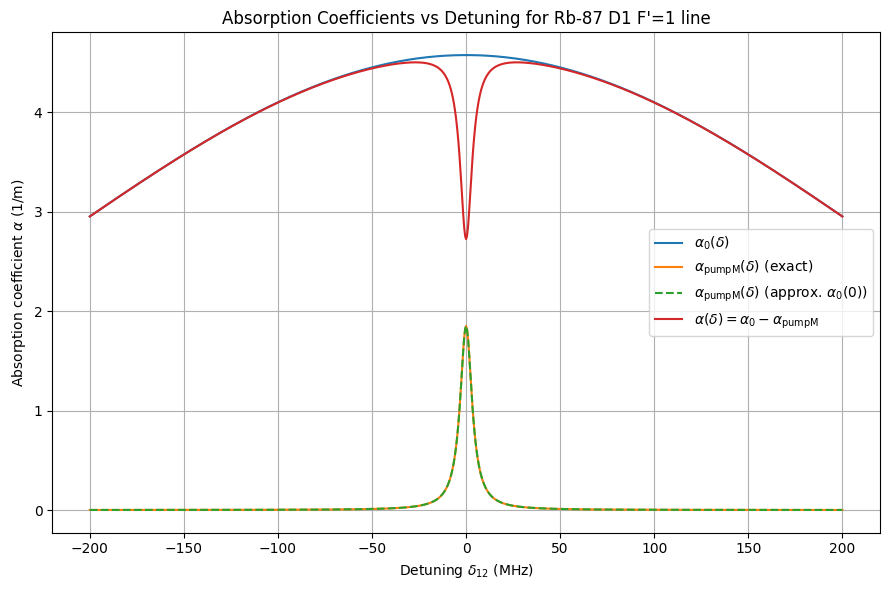

K_mSAS = 0.404522
Γ_mSAS = 7.703 MHz
α₀(0) = 4.574e+00 1/m


In [6]:
# in this visualization, the use of alpha_0(delta) and the delta->0 (alpha_0(0)) approximation is compared

# Detuning range (MHz → Hz)
delta_MHz = np.linspace(-200, 200, 801)
delta_Hz = delta_MHz * 1e6

# Compute α₀(δ)
alpha0_vals = compute_alpha0_numeric(delta_Hz, N, sigma_D11_0, u, lambda_D11, Gamma_D1)

# α₀(0) for approximation
alpha0_0 = np.interp(0.0, delta_Hz, alpha0_vals)

# Compute pump modification
alpha_pumpM_exact, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_Hz, I_pu_D1, I_sat_D11, Gamma_D1)
alpha_pumpM_approx = alpha0_0 * K_mSAS * L(delta_Hz, Gamma_mSAS)

# Final α(δ)
alpha_total_exact = alpha0_vals - alpha_pumpM_exact
alpha_total_approx = alpha0_vals - alpha_pumpM_approx

# Plot
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, alpha0_vals, label=r'$\alpha_0(\delta)$')
plt.plot(delta_MHz, alpha_pumpM_exact, label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (exact)')
plt.plot(delta_MHz, alpha_pumpM_approx, '--', label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (approx. $\alpha_0(0)$)')
plt.plot(delta_MHz, alpha_total_exact, label=r'$\alpha(\delta) = \alpha_0 - \alpha_{\mathrm{pumpM}}$')
plt.xlabel(r'Detuning $\delta_{12}$ (MHz)')
plt.ylabel(r'Absorption coefficient $\alpha$ (1/m)')
plt.title("Absorption Coefficients vs Detuning for Rb-87 D1 F'=1 line")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"K_mSAS = {K_mSAS:.6f}")
print(f"Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")
print(f"α₀(0) = {alpha0_0:.3e} 1/m")


### D1 to F'=1 and F'=2

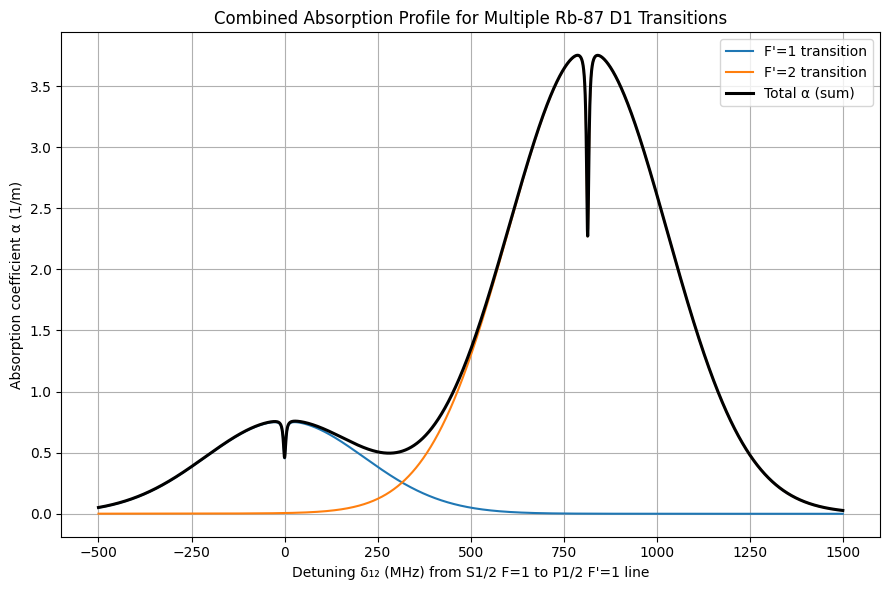

In [7]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]
transitions_ref_D1 = transitions.copy()

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[0]["f0"]
for tr in transitions:
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"], v_max_factor=7.0, n_v=20001)
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_shifted_Hz, I_pu_D1, tr["I_sat"], tr["Gamma"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Rb-87 D1 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# testing fitting of Lorentzian to the dip

# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]
transitions_ref_D1 = transitions.copy()

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)

zero_f = transitions[0]["f0"]
alpha0_vals = []
for tr in transitions:
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals.append(compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"], v_max_factor=7.0, n_v=20001))
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals[-1], delta_shifted_Hz, I_pu_D1, tr["I_sat"], tr["Gamma"])
    alpha_vals = tr["strength"] * (alpha0_vals[-1] - alpha_pumpM)
    alpha_total += alpha_vals

    # Fit Lorentzian to the pump-modified absorption dip
    def lorentzian(delta, A, delta0, gamma):
        return A * ( (gamma/2)**2 ) / ( (delta - delta0)**2 + (gamma/2)**2 ) 

    delta = delta_MHz
    signal = alpha_pumpM

    # Initial guesses:
    A0 = np.max(signal) - np.min(signal)
    delta0_guess = delta[np.argmax(signal)]
    gamma0 = 50  # MHz, rough guess

    p0 = [A0, delta0_guess, gamma0]

    # Fit using curve_fit
    popt, pcov = curve_fit(lorentzian, delta, signal, p0=p0)

    A_fit, delta0_fit, gamma_fit = popt

    print(f"\n==== {tr['label']} ====")
    print(f"Center detuning δ0 ≈ {delta0_fit:.3f} MHz")
    print(f"Linewidth FWHM Γ ≈ {gamma_fit:.3f} MHz")
    print(f"expected linewidth Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")




==== F'=1 ====
Center detuning δ0 ≈ -0.000 MHz
Linewidth FWHM Γ ≈ 7.698 MHz
expected linewidth Γ_mSAS = 7.703 MHz

==== F'=2 ====
Center detuning δ0 ≈ 814.500 MHz
Linewidth FWHM Γ ≈ 7.698 MHz
expected linewidth Γ_mSAS = 7.703 MHz


FWHM guesses (MHz): [500.2742550207332, 500.2753355331991]

=== Fitted Parameters ===
Gaussian 1: FWHM = 505.251 MHz
Gaussian 2: FWHM = 503.892 MHz

==== F'=1 ====
Center detuning δ0 ≈ 0.000 MHz
Linewidth FWHM Γ ≈ 7.683 MHz
expected linewidth Γ_mSAS = 7.703 MHz

==== F'=2 ====
Center detuning δ0 ≈ 814.500 MHz
Linewidth FWHM Γ ≈ -7.667 MHz
expected linewidth Γ_mSAS = 7.703 MHz


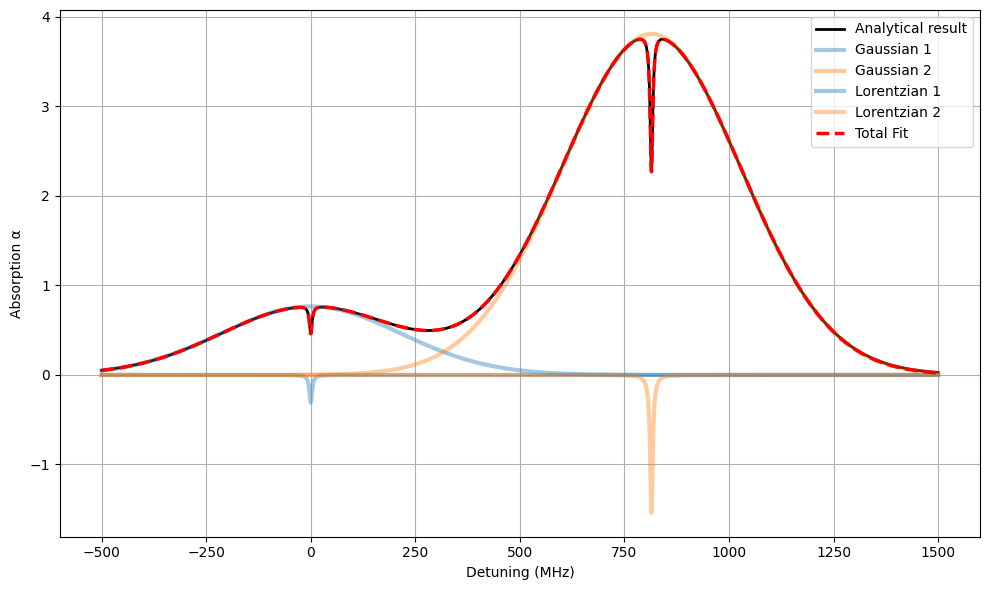

In [9]:
# # Now fitting multiple peaks (Gaussians) and dips (Lorentzians) to the total absorption profile
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2 / (2*sigma**2))

def lorentzian(x, A, x0, gamma):
    return A * ( (gamma/2)**2 ) / ( (x-x0)**2 + (gamma/2)**2 )

def total_model(delta, 
                A1, mu1, sigma1,
                A2, mu2, sigma2,
                *lorentz_params):
    # lorentz_params = [A3, x03, gamma3, A4, x04, gamma4, ...]
    result = gaussian(delta, A1, mu1, sigma1) \
           + gaussian(delta, A2, mu2, sigma2)

    # each Lorentzian has 3 parameters
    for j in range(0, len(lorentz_params), 3):
        Aj = lorentz_params[j]
        x0j = lorentz_params[j+1]
        gammaj = lorentz_params[j+2]
        result += lorentzian(delta, Aj, x0j, gammaj)

    return result

# Suppose you know approximate peaks:
guess_gaussians = [
    [np.max(alpha0_vals[0]),  delta_MHz[np.argmax(alpha0_vals[0])], u/(np.sqrt(2) * transitions[0]['lambda0']) * 1e-6],   # [A, mu, sigma]
    [np.max(alpha0_vals[1]), delta_MHz[np.argmax(alpha0_vals[1])], u/(np.sqrt(2) * transitions[1]['lambda0']) * 1e-6]
]
print("FWHM guesses (MHz):", [2*np.sqrt(2*np.log(2))*g[2] for g in guess_gaussians])

# Suppose you have n lorentzian dips:
lorentz_centers = [(transitions[0]['f0']-zero_f) * 1e-6, (transitions[1]['f0']-zero_f) * 1e-6]   # <-- your rough guesses
n = len(lorentz_centers)

guess_lorentzians = []
for c in lorentz_centers:
    guess_lorentzians += [-0.4, c, 30]   # [A, x0, gamma]

p0 = []
for g in guess_gaussians:
    p0 += g
p0 += guess_lorentzians

popt, pcov = curve_fit(total_model, delta_MHz, alpha_total, p0=p0)

fwhm_gaussians = []
fwhm_lorentzians = []

# Extract
idx = 0
for i in range(2):        # 2 Gaussians
    A, mu, sigma = popt[idx:idx+3]
    fwhm_gaussians.append(2*np.sqrt(2*np.log(2))*sigma)
    idx += 3

for j in range(n):        # n Lorentzians
    A, x0, gamma = popt[idx:idx+3]
    fwhm_lorentzians.append(gamma)
    idx += 3

# Make fitted curve
fit_curve = total_model(delta_MHz, *popt)

plt.figure(figsize=(10,6))

# Raw experimental data
plt.plot(delta_MHz, alpha_total, 'k', label='Analytical result', lw=2)

# Plot Gaussians
idx = 0
colors = ['tab:blue', 'tab:orange']
for i in range(2):
    A, mu, sigma = popt[idx:idx+3]
    comp = gaussian(delta_MHz, A, mu, sigma)
    plt.plot(delta_MHz, comp, color=colors[i], alpha=0.4, lw=3,
             label=f"Gaussian {i+1}")
    idx += 3

# Plot Lorentzians
for j in range(n):
    A, x0, gamma = popt[idx:idx+3]
    comp = lorentzian(delta_MHz, A, x0, gamma)
    plt.plot(delta_MHz, comp, alpha=0.4, lw=3,
             label=f"Lorentzian {j+1}")
    idx += 3

print("\n=== Fitted Parameters ===")
for i in range(2):
    print(f"Gaussian {i+1}: FWHM = {fwhm_gaussians[i]:.3f} MHz")
for j in range(n):
    print(f"\n==== {transitions[j]['label']} ====")
    print(f"Center detuning δ0 ≈ {popt[6+3*j+1]:.3f} MHz")
    print(f"Linewidth FWHM Γ ≈ {popt[6+3*j+2]:.3f} MHz")
    print(f"expected linewidth Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")

# Total fitted model
plt.plot(delta_MHz, fit_curve, 'r--', lw=2.5, label='Total Fit')

plt.xlabel("Detuning (MHz)")
plt.ylabel("Absorption α")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### D2

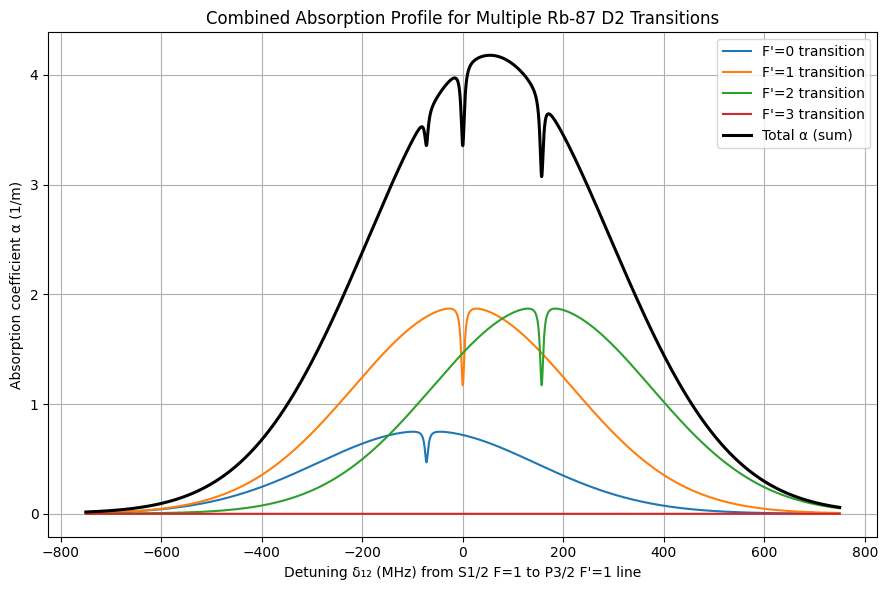

In [10]:
# Detuning range
delta_MHz = np.linspace(-750, 750, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D2_10, "f0": f_D20, "sigma0": sigma_D20_0, "lambda0": lambda_D20, "Gamma": Gamma_D2, "I_sat": I_sat_D20, "label": "F'=0"},
    {"strength":S_coeff_D2_11, "f0": f_D21, "sigma0": sigma_D21_0, "lambda0": lambda_D21, "Gamma": Gamma_D2, "I_sat": I_sat_D21, "label": "F'=1"},
    {"strength":S_coeff_D2_12, "f0": f_D22, "sigma0": sigma_D22_0, "lambda0": lambda_D22, "Gamma": Gamma_D2, "I_sat": I_sat_D22, "label": "F'=2"},
    {"strength":0, "f0": f_D23, "sigma0": sigma_D23_0, "lambda0": lambda_D23, "Gamma": Gamma_D2, "I_sat": I_sat_D23, "label": "F'=3"},
]
transitions_ref_D2 = transitions.copy()

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[1]["f0"]
for tr in transitions:
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"])
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_shifted_Hz, I_pu_D2, tr["I_sat"], tr["Gamma"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P3/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Rb-87 D2 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### bSAS D1 

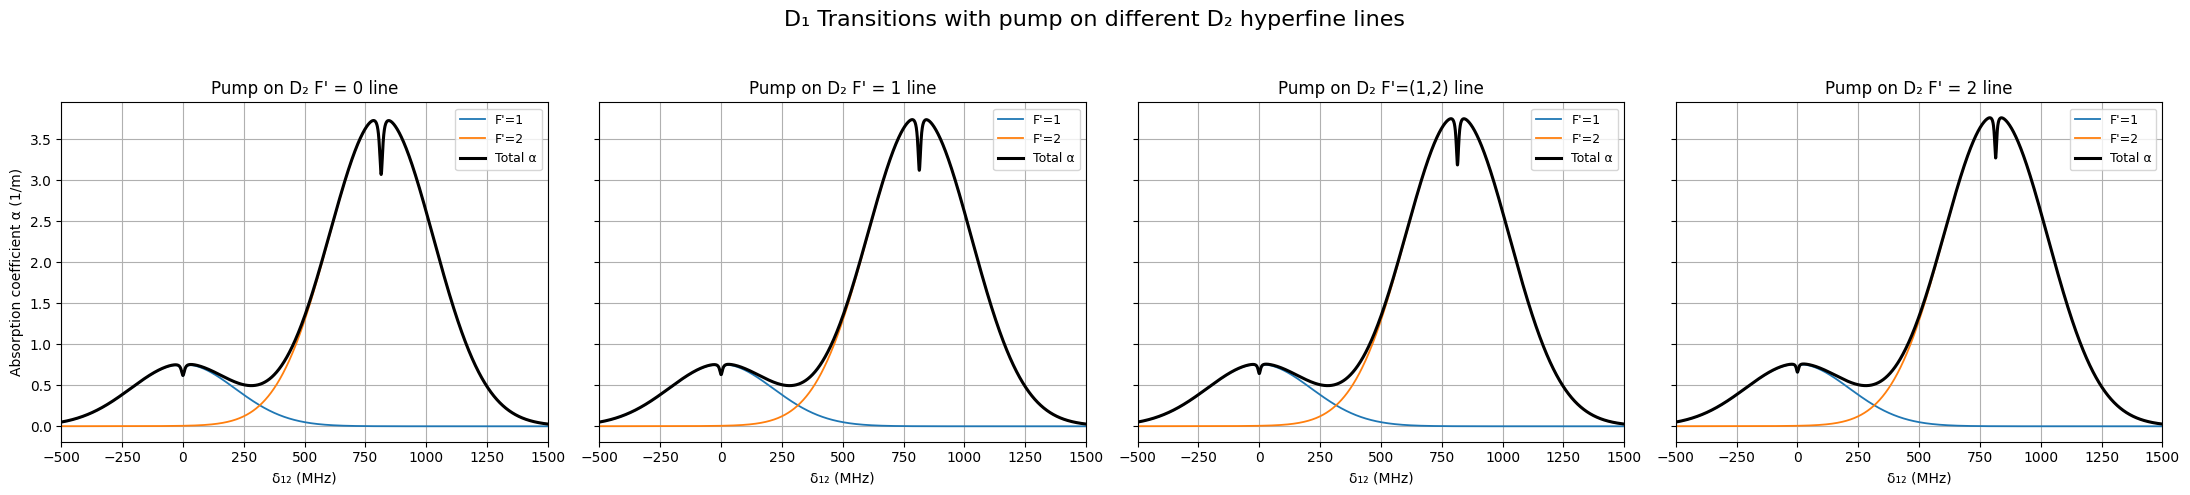

In [11]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6
delta_13 = 0.0 # pump in resonance

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
pump_labels = [r"F' = 0", r"F' = 1", r"F'=(1,2)", r"F' = 2"]
pump_lambdas = [lambda_D20, lambda_D21, ((1/lambda_D21 + 1/lambda_D22)/2)**(-1),lambda_D22]
Gamma_3 = [Gamma_D20, Gamma_D21, (Gamma_D21 + Gamma_D22)/2, Gamma_D22] # use average linewidth for (1,2) case as approximation
I_sat_arr = [I_sat_D20, I_sat_D21, (I_sat_D21 + I_sat_D22)/2, I_sat_D22]

for ax, Gamma_3_val, lambda_3, lbl in zip(axes, Gamma_3, pump_lambdas, pump_labels):
    alpha_total = np.zeros_like(delta_Hz)
    zero_f = transitions[0]["f0"]
    i=0
    for tr in transitions:
        i+=1
        # Compute α for each transition and sum
        delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
        alpha0_vals = compute_alpha0_numeric(
            delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"]
        )

        # wavelength mismatch between probe and pump
        epsilon = tr["lambda0"] / lambda_3 - 1

        # use corrected compute_pumpB (the fixed version)
        alpha_pumpB, K_bSAS, Gamma_bSAS = compute_pumpB(
            alpha0_vals, delta_shifted_Hz, delta_13,
            I_pu_D2, I_sat_arr[i-1], tr["Gamma"], Gamma_3_val, epsilon
        )

        alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpB)
        alpha_total += alpha_vals

        ax.plot(delta_MHz, alpha_vals, lw=1.3, label=fr"{tr['label']}")

    # total absorption (black thick line)
    ax.plot(delta_MHz, alpha_total, "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {lbl} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### bSAS D1 with pump detuning

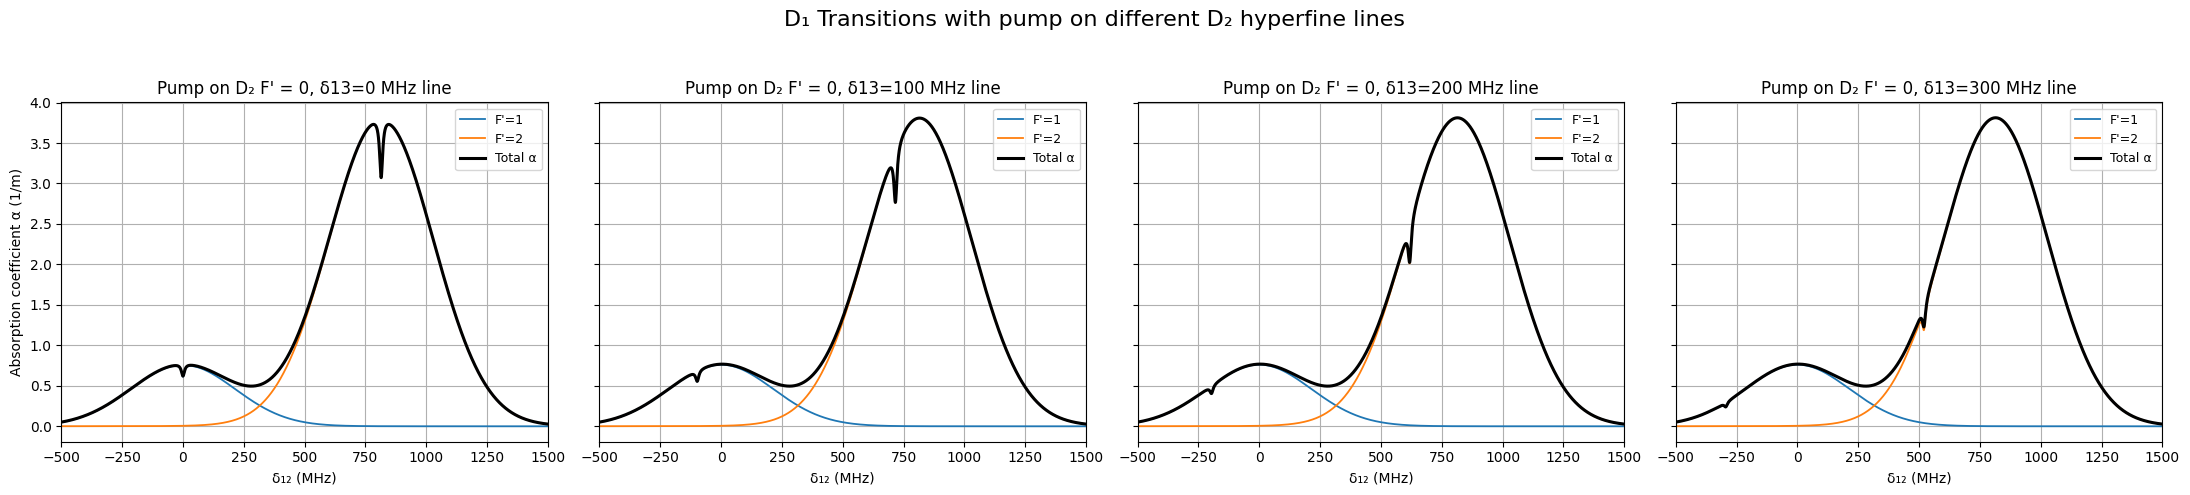

In [12]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6
delta_13 = [0, 100e6, 200e6, 300e6] # pump in resonance

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
pump_labels = [fr"F' = 0, δ13={d_13/1e6:.0f} MHz" for d_13 in delta_13]
pump_lambdas = [lambda_D20, lambda_D20, lambda_D20,lambda_D20]
Gamma_3 = [Gamma_D20, Gamma_D20, Gamma_D20, Gamma_D20] # use average linewidth for (1,2) case as approximation
I_sat_arr = [I_sat_D20, I_sat_D21, (I_sat_D21 + I_sat_D22)/2, I_sat_D22]

for ax, d_13, Gamma_3_val, lambda_3, lbl in zip(axes, delta_13, Gamma_3, pump_lambdas, pump_labels):
    alpha_total = np.zeros_like(delta_Hz)
    zero_f = transitions[0]["f0"]
    i=0
    for tr in transitions:
        i+=1
        # Compute α for each transition and sum
        delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
        alpha0_vals = compute_alpha0_numeric(
            delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"]
        )

        # wavelength mismatch between probe and pump
        epsilon = tr["lambda0"] / lambda_3 - 1

        # use corrected compute_pumpB (the fixed version)
        alpha_pumpB, K_bSAS, Gamma_bSAS = compute_pumpB(
            alpha0_vals, delta_shifted_Hz, d_13,
            I_pu_D2, I_sat_arr[i-1], tr["Gamma"], Gamma_3_val, epsilon
        )

        alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpB)
        alpha_total += alpha_vals

        ax.plot(delta_MHz, alpha_vals, lw=1.3, label=fr"{tr['label']}")

    # total absorption (black thick line)
    ax.plot(delta_MHz, alpha_total, "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {lbl} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


# With line broadening

## Constants

In [13]:
# Saturation and pump intensities
I_psat_D11 = I_sat_D11 * (1+Gamma_tr_D1/(Gamma_D11+Gamma_D11_d))/(1+Gamma_D11_d/(2*Gamma_tr_D1))
I_psat_D12 = I_sat_D12 * (1+Gamma_tr_D1/(Gamma_D12+Gamma_D12_d))/(1+Gamma_D12_d/(2*Gamma_tr_D1))
# I_pu_D1 = I_psat_D11  # set equal I_sat_D11
I_pu_D1 = 1.3 * 10 # mW/cm^2
print(f"I_pu_D1 = {I_pu_D1/10:.2f} mW/cm^2 I_psat_D11 = {I_psat_D11/10:.2f} mW/cm^2")

I_psat_D20 = I_sat_D20 * (1+Gamma_tr_D2/(Gamma_D20+Gamma_D20_d))/(1+Gamma_D20_d/(2*Gamma_tr_D2))
I_psat_D21 = I_sat_D21 * (1+Gamma_tr_D2/(Gamma_D21+Gamma_D21_d))/(1+Gamma_D21_d/(2*Gamma_tr_D2))
I_psat_D22 = I_sat_D22 * (1+Gamma_tr_D2/(Gamma_D22+Gamma_D22_d))/(1+Gamma_D22_d/(2*Gamma_tr_D2))
I_psat_D23 = I_sat_D23 * (1+Gamma_tr_D2/(Gamma_D23+Gamma_D23_d))/(1+Gamma_D23_d/(2*Gamma_tr_D2))
I_pu_D2 = I_psat_D21  # set equal I_sat_D21
I_pu_D2 = 1.3 * 10 # mW/cm^2
print(f"I_pu_D2 = {I_pu_D2/10:.2f} mW/cm^2 I_psat_D21 = {I_psat_D21/10:.2f} mW/cm^2")

print(f"Gamma_d = {Gamma_D11_d/1e6:.2f} MHz for D1 F'=1 and {Gamma_D12_d/1e6:.2f} MHz for D1 F'=2")
print(f"Gamma_tr_D1 = {Gamma_tr_D1/1e6:.2f} MHz")
print(f"Gamma_tr_D2 = {Gamma_tr_D2/1e6:.2f} MHz")

I_pu_D1 = 1.30 mW/cm^2 I_psat_D11 = 0.09 mW/cm^2
I_pu_D2 = 1.30 mW/cm^2 I_psat_D21 = 0.22 mW/cm^2
Gamma_d = 4.79 MHz for D1 F'=1 and 2.88 MHz for D1 F'=2
Gamma_tr_D1 = 0.34 MHz
Gamma_tr_D2 = 0.18 MHz


## Algorithm

### mSAS

In [14]:
def compute_pumpM_tilde(alpha0_delta, delta_array_Hz, I_pu, I_psat, Gamma2_tilde):
    """
    Computes α_pumpM(δ) = α₀(δ) * K_mSAS_tilde * L_tilde(δ, Γ_mSAS).
    """
    K_mSAS_tilde = 1 - (1 + I_pu / I_psat)**(-0.5)
    Gamma_mSAS_tilde = (Gamma2_tilde / 2) * (1 + np.sqrt(1 + I_pu / I_psat))
    L_vals = L(delta_array_Hz, Gamma_mSAS_tilde)
    alpha_pumpM = alpha0_delta * K_mSAS_tilde * L_vals
    return alpha_pumpM, K_mSAS_tilde, Gamma_mSAS_tilde

### bSAS

In [15]:
def L_tilde(delta, Gamma_tilde, I_pu, I_psat):
    """Modified Lorentzian lineshape considering transit-time broadening."""
    factor = np.sqrt(1 + I_pu / I_psat)
    Gamma_effective = Gamma_tilde * factor
    return ((Gamma_effective**2) / 4) / (delta**2 + (Gamma_effective**2) / 4)

def compute_pumpB_tilde(alpha0_delta, delta_array_Hz, delta_13, I_pu, I_psat, Gamma2_tilde, Gamma3_tilde, Gamma3_d, Gamma_tr, epsilon):
    """
    Computes α_pumpB(δ) = α₀(δ) * K_bSAS * L(δ, Γ_bSAS).
    """
    temp = (1+I_pu/I_psat)**(0.5)
    K_bSAS_tilde = (1+Gamma3_d/Gamma_tr)/(1+Gamma3_d/(2*Gamma_tr)) * (I_pu/I_psat)/(temp*(Gamma2_tilde/Gamma3_tilde * (1+epsilon) + temp))
    Gamma_bSAS_tilde = Gamma2_tilde + Gamma3_tilde/(1+epsilon) * temp
    L_vals_tilde = L_tilde(delta_array_Hz + delta_13/(1+epsilon), Gamma_bSAS_tilde, I_pu, I_psat)
    alpha_pumpB = alpha0_delta/2 * K_bSAS_tilde * L_vals_tilde
    return alpha_pumpB, K_bSAS_tilde, Gamma_bSAS_tilde

## Visualization

### D1 mSAS

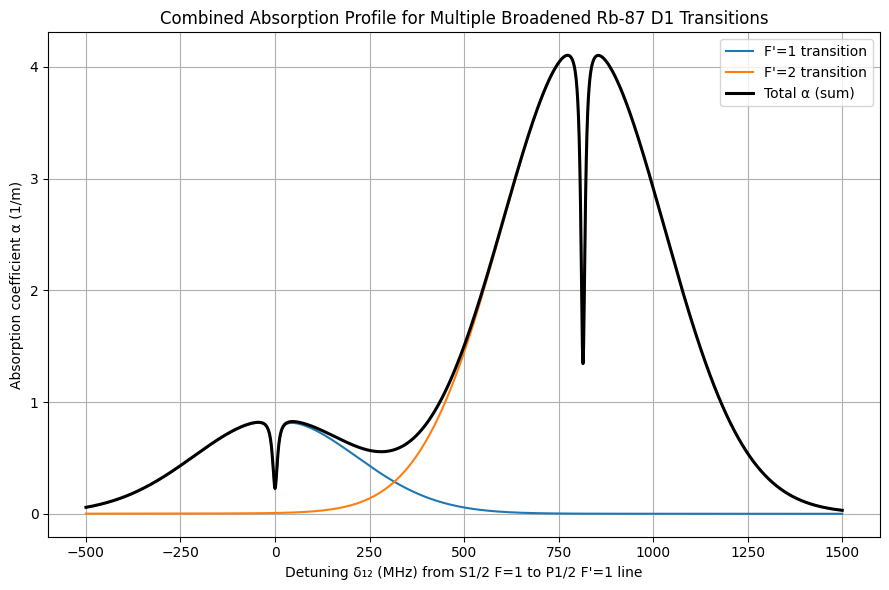

Supposed peak height: 4.6231426341377295


In [16]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
# or some reason sigma0 is the same but the linewidths are modified
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma_tilde": Gamma_D11+Gamma_D11_d+2*Gamma_tr_D1, "I_psat": I_psat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma_tilde": Gamma_D12+Gamma_D12_d+2*Gamma_tr_D1, "I_psat": I_psat_D12, "label": "F'=2"},
]

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

def compute_alpha0_numeric_1(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        alpha0[i] = N * sigma0 * f_D(delta/k_freq, u) * np.pi * Gamma2 / (2 * k_freq)
    print(f_D(0,u) * np.pi**2)
    return alpha0

zero_f = transitions[0]["f0"]
i=0
for tr in transitions:
    i+=1
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"], v_max_factor=5.0, n_v=2001)
    # alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, transitions_ref_D1[i-1]["sigma0"], u, tr["lambda0"], transitions_ref_D1[i-1]["Gamma"])
    # alpha0_vals = compute_alpha0_numeric_1(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])
    # alpha0_vals = compute_alpha0_numeric_1(delta_shifted_Hz, N, transitions_ref_D1[i-1]["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])
    alpha_pumpM, K_mSAS_tilde, Gamma_mSAS_tilde = compute_pumpM_tilde(alpha0_vals, delta_shifted_Hz, I_pu_D1, tr["I_psat"], tr["Gamma_tilde"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Broadened Rb-87 D1 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Supposed peak height: {N*3*lambda_D11**2/(2*np.pi) * f_D(0,u) * ( np.pi * Gamma_D1 / (2/lambda_D11) )  / 3}")


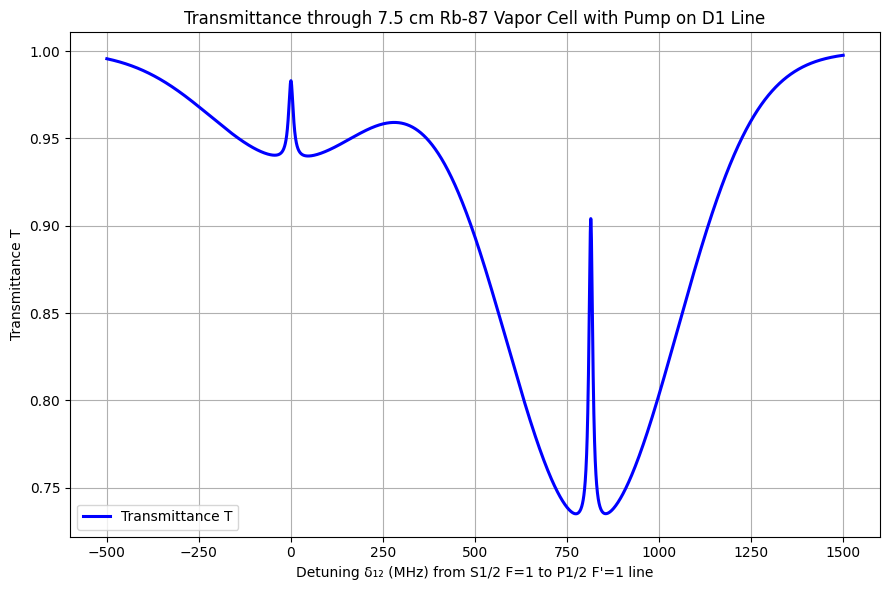

In [17]:
# Transmittance calculation
L_cell = 75e-3  # 75 mm 
T_total = np.exp(-alpha_total * L_cell)
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, T_total, 'b', linewidth=2.2, label="Transmittance T")
plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Transmittance T')
plt.title(f'Transmittance through {L_cell*100:.1f} cm Rb-87 Vapor Cell with Pump on D1 Line')
# plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

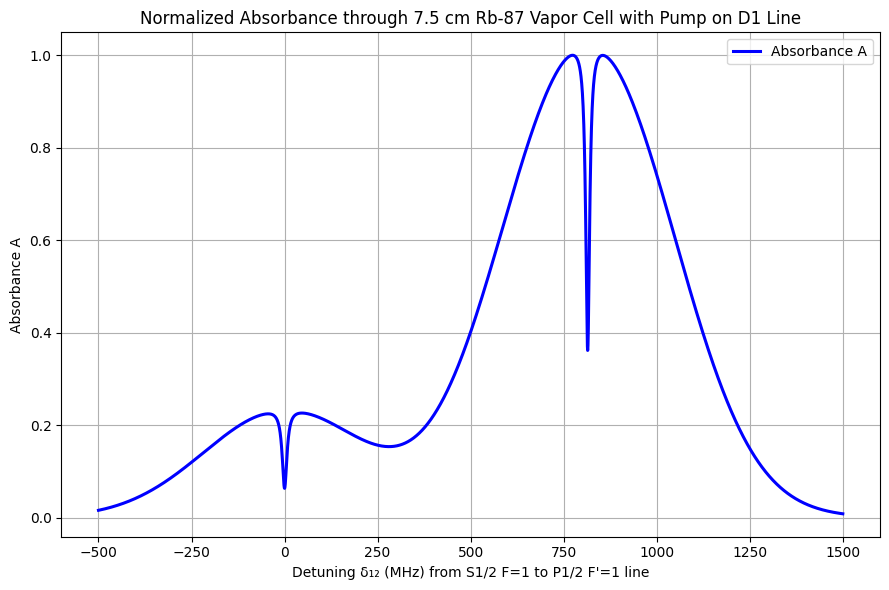

In [18]:
# Absorbance calculation
L_cell = 75e-3  # 75 mm 
A_total = 1-np.exp(-alpha_total * L_cell)
A_total = A_total / np.max(A_total)  # normalize to max 1 for visualization
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, A_total, 'b', linewidth=2.2, label="Absorbance A")
plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorbance A')
plt.title(f'Normalized Absorbance through {L_cell*100:.1f} cm Rb-87 Vapor Cell with Pump on D1 Line')
# plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### D2 mSAS

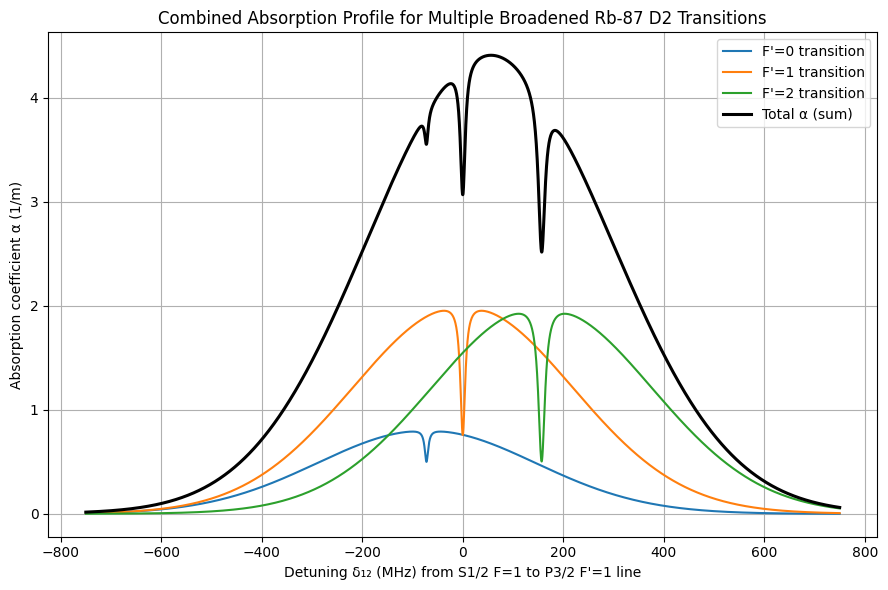

In [24]:
# Detuning range
delta_MHz = np.linspace(-750, 750, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D2_10, "f0": f_D20, "sigma0": sigma_D20_0, "lambda0": lambda_D20, "Gamma_tilde": Gamma_D20+Gamma_D20_d+2*Gamma_tr_D2, "Gamma": Gamma_D20+Gamma_D20_d, "I_psat": I_psat_D20, "label": "F'=0"},
    {"strength":S_coeff_D2_11, "f0": f_D21, "sigma0": sigma_D21_0, "lambda0": lambda_D21, "Gamma_tilde": Gamma_D21+Gamma_D21_d+2*Gamma_tr_D2, "Gamma": Gamma_D21+Gamma_D21_d, "I_psat": I_psat_D21, "label": "F'=1"},
    {"strength":S_coeff_D2_12, "f0": f_D22, "sigma0": sigma_D22_0, "lambda0": lambda_D22, "Gamma_tilde": Gamma_D22+Gamma_D22_d+2*Gamma_tr_D2, "Gamma": Gamma_D22+Gamma_D22_d, "I_psat": I_psat_D22, "label": "F'=2"},
    # {"strength":0, "f0": f_D23, "sigma0": sigma_D23_0, "lambda0": lambda_D23, "Gamma_tilde": Gamma_D23+Gamma_D23_d+2*Gamma_tr_D2, "I_psat": I_psat_D23, "label": "F'=3"},
]

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[1]["f0"]
i=0
alpha0_vals_arr = []
Gamma_mSAS_arr = []
for tr in transitions:
    i+=1
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    # alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, transitions_ref_D2[i-1]["sigma0"], u, tr["lambda0"], transitions_ref_D2[i-1]["Gamma"])
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])
    alpha0_vals_arr.append(alpha0_vals)
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM_tilde(alpha0_vals, delta_shifted_Hz, I_pu_D2, tr["I_psat"], tr["Gamma_tilde"])
    Gamma_mSAS_arr.append(Gamma_mSAS)
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P3/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Broadened Rb-87 D2 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


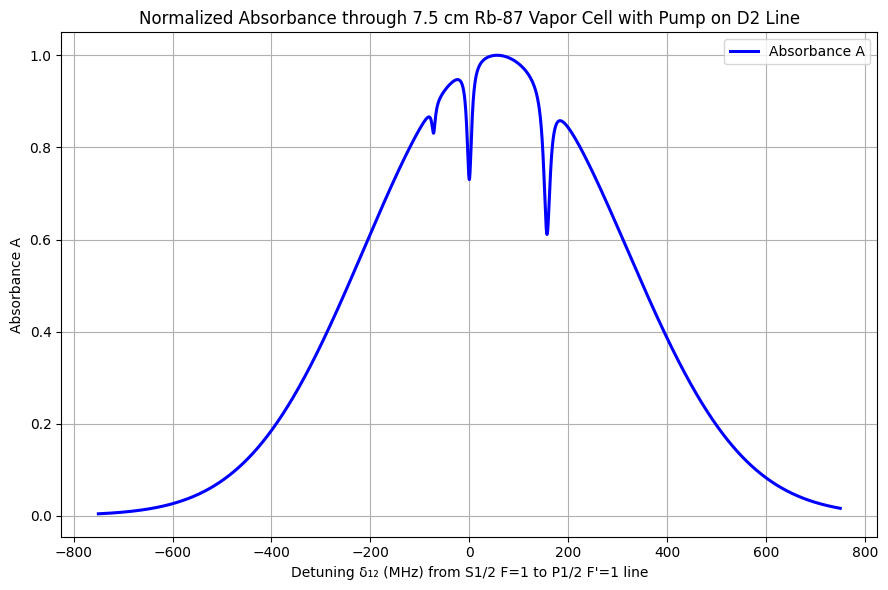

In [20]:
# Absorbance calculation
L_cell = 75e-3  # 75 mm 
A_total = 1-np.exp(-alpha_total * L_cell)
A_total = A_total / np.max(A_total)  # normalize to max 1 for visualization
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, A_total, 'b', linewidth=2.2, label="Absorbance A")
plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorbance A')
plt.title(f'Normalized Absorbance through {L_cell*100:.1f} cm Rb-87 Vapor Cell with Pump on D2 Line')
# plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

FWHM guesses (MHz): [509.72390110060127, 509.7239969047134, 509.72420510998035]

=== Fitted Parameters ===
Gaussian 1: FWHM = 491.923 MHz
Gaussian 2: FWHM = 508.390 MHz
Gaussian 3: FWHM = 505.472 MHz

==== F'=0 ====
Center detuning δ0 ≈ -72.215 MHz
Linewidth FWHM Γ ≈ 8.104 MHz
expected linewidth Γ_mSAS = 8.378 MHz
natural linewidth = 6.067 MHz

==== F'=1 ====
Center detuning δ0 ≈ -0.004 MHz
Linewidth FWHM Γ ≈ 11.548 MHz
expected linewidth Γ_mSAS = 11.736 MHz
natural linewidth = 6.067 MHz

==== F'=2 ====
Center detuning δ0 ≈ 156.970 MHz
Linewidth FWHM Γ ≈ 15.623 MHz
expected linewidth Γ_mSAS = 16.040 MHz
natural linewidth = 6.067 MHz

average ratio Γ_mSAS / natural linewidth =  1.9381934354428745


C:\Users\Dell\AppData\Local\Temp\ipykernel_15240\3635847807.py:48: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(total_model_3, delta_MHz, A_total, p0=p0, maxfev=10000)


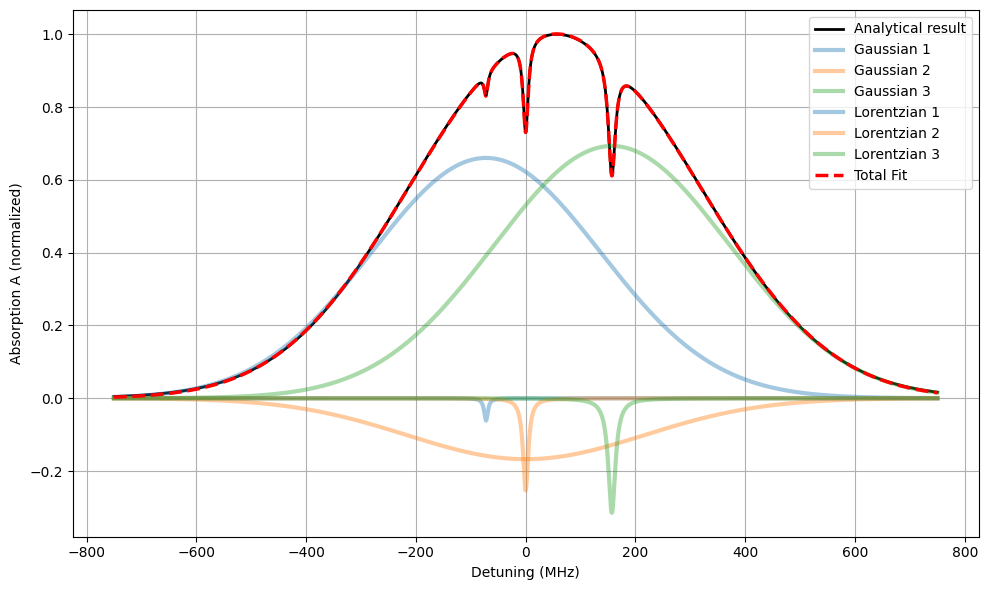

In [21]:
# # Now fitting multiple peaks (Gaussians) and dips (Lorentzians) to the total absorption profile
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2 / (2*sigma**2))

def lorentzian(x, A, x0, gamma):
    return A * ( (gamma/2)**2 ) / ( (x-x0)**2 + (gamma/2)**2 )

def total_model_3(delta, 
                A1, mu1, sigma1,
                A2, mu2, sigma2,
                A3, mu3, sigma3,
                *lorentz_params):
    # lorentz_params = [A3, x03, gamma3, A4, x04, gamma4, ...]
    result = gaussian(delta, A1, delta_MHz[np.argmax(alpha0_vals_arr[0])], sigma1) \
           + gaussian(delta, A2, delta_MHz[np.argmax(alpha0_vals_arr[1])], sigma2) \
            + gaussian(delta, A3, delta_MHz[np.argmax(alpha0_vals_arr[2])], sigma3)

    # each Lorentzian has 3 parameters
    for j in range(0, len(lorentz_params), 3):
        Aj = lorentz_params[j]
        x0j = lorentz_params[j+1]
        gammaj = lorentz_params[j+2]
        result += lorentzian(delta, Aj, x0j, gammaj)

    return result

# Suppose you know approximate peaks:
guess_gaussians = [
    [np.max(alpha0_vals_arr[0]),  delta_MHz[np.argmax(alpha0_vals_arr[0])], u/(np.sqrt(2) * transitions[0]['lambda0']) * 1e-6],   # [A, mu, sigma]
    [np.max(alpha0_vals_arr[1]), delta_MHz[np.argmax(alpha0_vals_arr[1])], u/(np.sqrt(2) * transitions[1]['lambda0']) * 1e-6],
    [np.max(alpha0_vals_arr[2]), delta_MHz[np.argmax(alpha0_vals_arr[2])], u/(np.sqrt(2) * transitions[2]['lambda0']) * 1e-6]
]
print("FWHM guesses (MHz):", [2*np.sqrt(2*np.log(2))*g[2] for g in guess_gaussians])

# Suppose you have n lorentzian dips:
lorentz_centers = [(transitions[0]['f0']-zero_f) * 1e-6, (transitions[1]['f0']-zero_f) * 1e-6, (transitions[2]['f0']-zero_f) * 1e-6]   # <-- your rough guesses
n = len(lorentz_centers)

guess_lorentzians = []
for c in lorentz_centers:
    guess_lorentzians += [-0.2, c, 30]   # [A, x0, gamma]

p0 = []
for g in guess_gaussians:
    p0 += g
p0 += guess_lorentzians

popt, pcov = curve_fit(total_model_3, delta_MHz, A_total, p0=p0, maxfev=10000)

fwhm_gaussians = []
fwhm_lorentzians = []

# Extract
idx = 0
for i in range(3):        # 3 Gaussians
    A, mu, sigma = popt[idx:idx+3]
    fwhm_gaussians.append(2*np.sqrt(2*np.log(2))*sigma)
    idx += 3

for j in range(n):        # n Lorentzians
    A, x0, gamma = popt[idx:idx+3]
    fwhm_lorentzians.append(gamma)
    idx += 3

# Make fitted curve
fit_curve = total_model_3(delta_MHz, *popt)

plt.figure(figsize=(10,6))

# Raw experimental data
plt.plot(delta_MHz, A_total, 'k', label='Analytical result', lw=2)

# Plot Gaussians
idx = 0
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    A, mu, sigma = popt[idx:idx+3]
    comp = gaussian(delta_MHz, A, mu, sigma)
    plt.plot(delta_MHz, comp, color=colors[i], alpha=0.4, lw=3,
             label=f"Gaussian {i+1}")
    idx += 3

# Plot Lorentzians
for j in range(n):
    A, x0, gamma = popt[idx:idx+3]
    comp = lorentzian(delta_MHz, A, x0, gamma)
    plt.plot(delta_MHz, comp, alpha=0.4, lw=3,
             label=f"Lorentzian {j+1}")
    idx += 3

print("\n=== Fitted Parameters ===")
for i in range(3):
    print(f"Gaussian {i+1}: FWHM = {fwhm_gaussians[i]:.3f} MHz")
for j in range(n):
    print(f"\n==== {transitions[j]['label']} ====")
    print(f"Center detuning δ0 ≈ {popt[9+3*j+1]:.3f} MHz")
    print(f"Linewidth FWHM Γ ≈ {popt[9+3*j+2]:.3f} MHz")
    print(f"expected linewidth Γ_mSAS = {Gamma_mSAS_arr[j]/1e6:.3f} MHz")
    print(f"natural linewidth = {(transitions[j]['Gamma'])/1e6:.3f} MHz")

print()
print("average ratio Γ_mSAS / natural linewidth = ",
      np.mean([np.abs(popt[9+3*j+2])*1e6/(transitions[j]['Gamma']) for j in range(n)]))

# Total fitted model
plt.plot(delta_MHz, fit_curve, 'r--', lw=2.5, label='Total Fit')

plt.xlabel("Detuning (MHz)")
plt.ylabel("Absorption A (normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


D1 bSAS

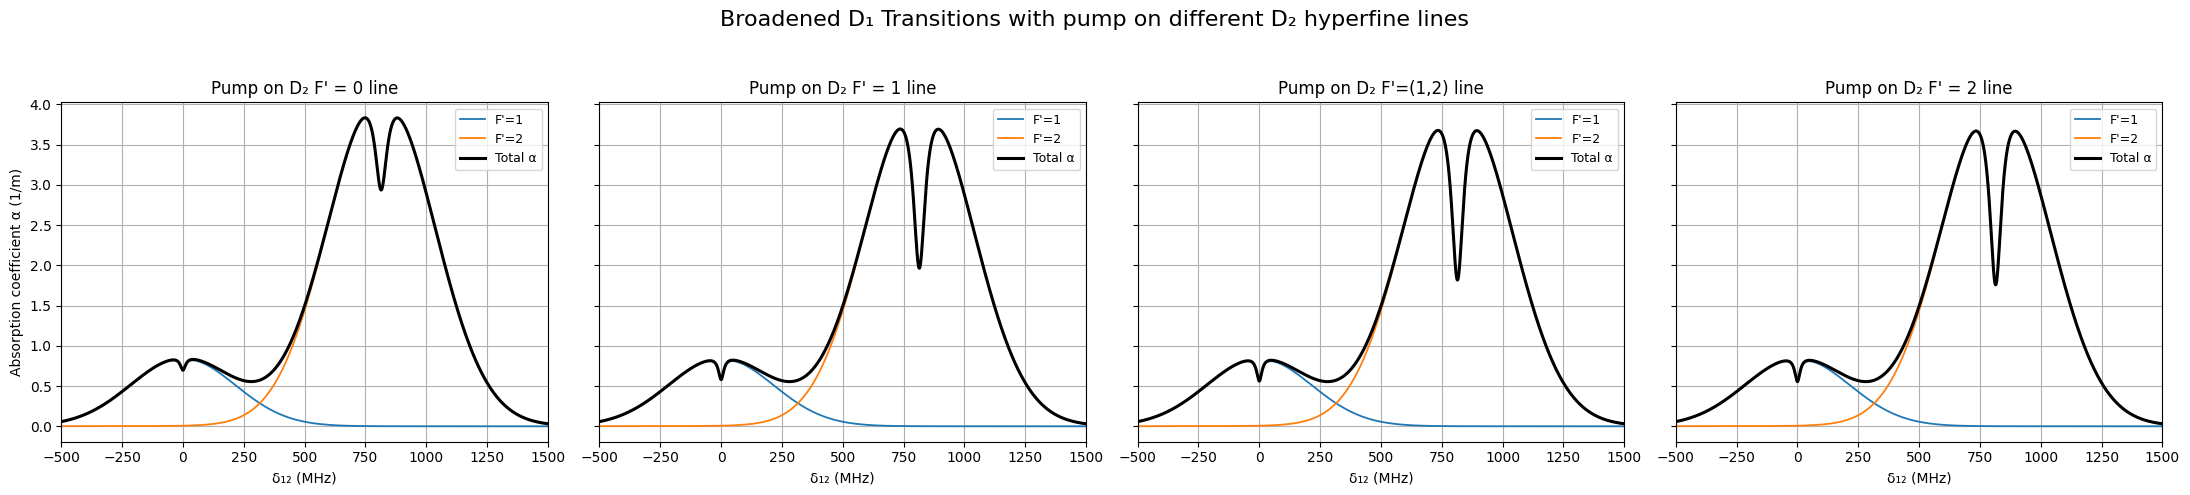

In [22]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6
delta_13 = 0.0 # pump in resonance

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma_tilde": Gamma_D11+Gamma_D11_d+2*Gamma_tr_D1, "I_psat": I_psat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma_tilde": Gamma_D12+Gamma_D12_d+2*Gamma_tr_D1, "I_psat": I_psat_D12, "label": "F'=2"},
]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
pump_labels = [r"F' = 0", r"F' = 1", r"F'=(1,2)", r"F' = 2"]
pump_lambdas = [lambda_D20, lambda_D21, ((1/lambda_D21 + 1/lambda_D22)/2)**(-1),lambda_D22]
Gamma_3 = [Gamma_D20, Gamma_D21, (Gamma_D21 + Gamma_D22)/2, Gamma_D22] # use average linewidth for (1,2) case as approximation
Gamma_3_d = [Gamma_D20_d, Gamma_D21_d, (Gamma_D21_d + Gamma_D22_d)/2, Gamma_D22_d] # use average linewidth for (1,2) case as approximation
I_psat_arr = [I_psat_D20, I_psat_D21, (I_psat_D21 + I_psat_D22)/2, I_psat_D22]

for ax, Gamma_3_d_val, Gamma_3_val, lambda_3, lbl in zip(axes, Gamma_3_d, Gamma_3, pump_lambdas, pump_labels):
    alpha_total = np.zeros_like(delta_Hz)
    zero_f = transitions[0]["f0"]
    i=0
    for tr in transitions:
        i+=1
        # Compute α for each transition and sum
        delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
        # alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, transitions_ref_D1[i-1]["sigma0"], u, tr["lambda0"], transitions_ref_D1[i-1]["Gamma"])
        alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])

        # wavelength mismatch between probe and pump
        epsilon = tr["lambda0"] / lambda_3 - 1

        # use corrected compute_pumpB (the fixed version)
        alpha_pumpB, K_bSAS, Gamma_bSAS = compute_pumpB_tilde(
            alpha0_vals, delta_shifted_Hz, delta_13,
            I_pu_D2, I_psat_arr[i-1], tr["Gamma_tilde"], 
            Gamma_3_val+Gamma_3_d_val+2*Gamma_tr_D2, Gamma_3_d_val, Gamma_tr_D2, epsilon
        )

        alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpB)
        alpha_total += alpha_vals

        ax.plot(delta_MHz, alpha_vals, lw=1.3, label=fr"{tr['label']}")

    # total absorption (black thick line)
    ax.plot(delta_MHz, alpha_total, "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {lbl} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("Broadened D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
